<a href="https://colab.research.google.com/github/soup511/OIBSIP/blob/main/SouptikaDas_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 2 · Unemployment Analysis with Python

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA)
on unemployment data in India to identify regional and temporal trends and
understand the impact of the COVID-19 pandemic on unemployment rates.

### Technologies Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

Load the Dataset

In [7]:
df=pd.read_csv("/content/Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Inspect the Dataset

In [8]:
df.shape

(768, 7)

In [10]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [12]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


Clean Column Names

In [14]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [15]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

Check Missing Values

In [16]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
Region,3.645833
Date,3.645833
Frequency,3.645833
Estimated Unemployment Rate (%),3.645833
Estimated Employed,3.645833
Estimated Labour Participation Rate (%),3.645833
Area,3.645833


In [19]:
df = df.dropna()
print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (740, 7)


Convert Date Column

In [20]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df['Date'].dtype)

datetime64[ns]


In [21]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00


Create Month and Year Columns

In [22]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Month_Name,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,September,2019


Region-wise Average Unemployment Rate

In [23]:
region_avg = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
)
region_avg

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


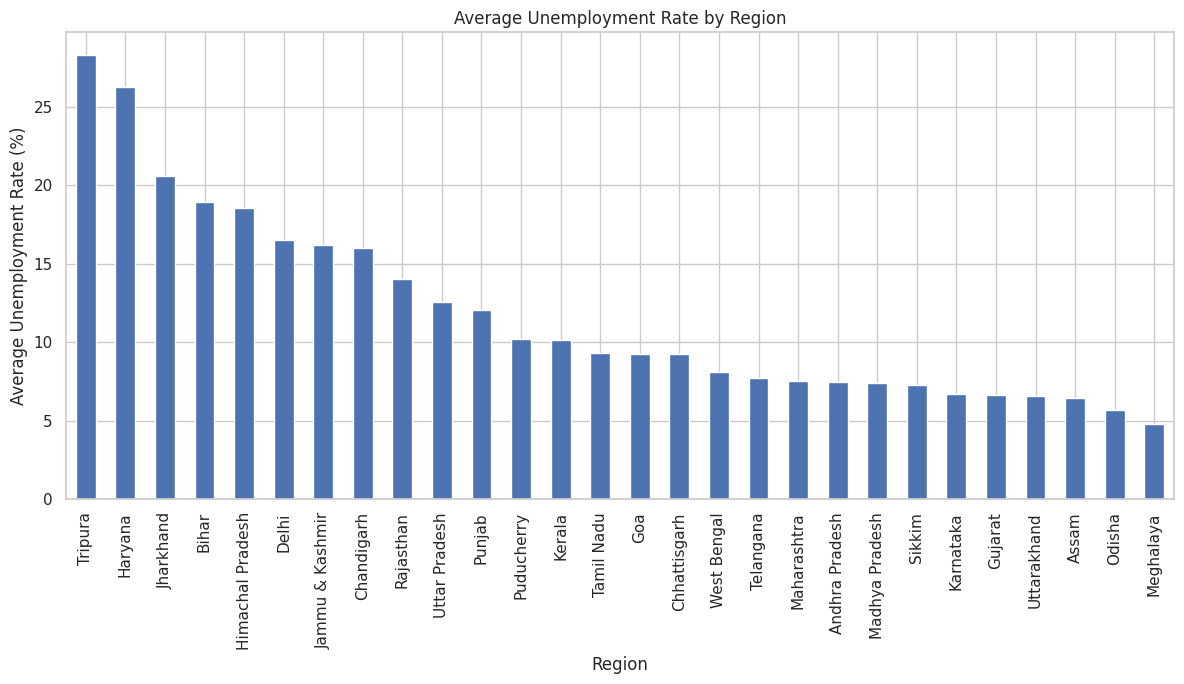

In [24]:
plt.figure(figsize=(12, 7))
region_avg.plot(kind='bar')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation

The average unemployment rate varies considerably across regions.
Some regions have substantially higher average unemployment rates,
while others have relatively lower unemployment rates. This indicates
regional differences in employment conditions across India.

In [25]:
monthly_avg = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
      .mean()
)
monthly_avg

,Estimated Unemployment Rate (%)
Month,
1,9.950755
2,9.964717
3,10.700577
4,23.641569
5,16.646190
6,10.553462
7,9.033889
8,9.637925
9,9.051731


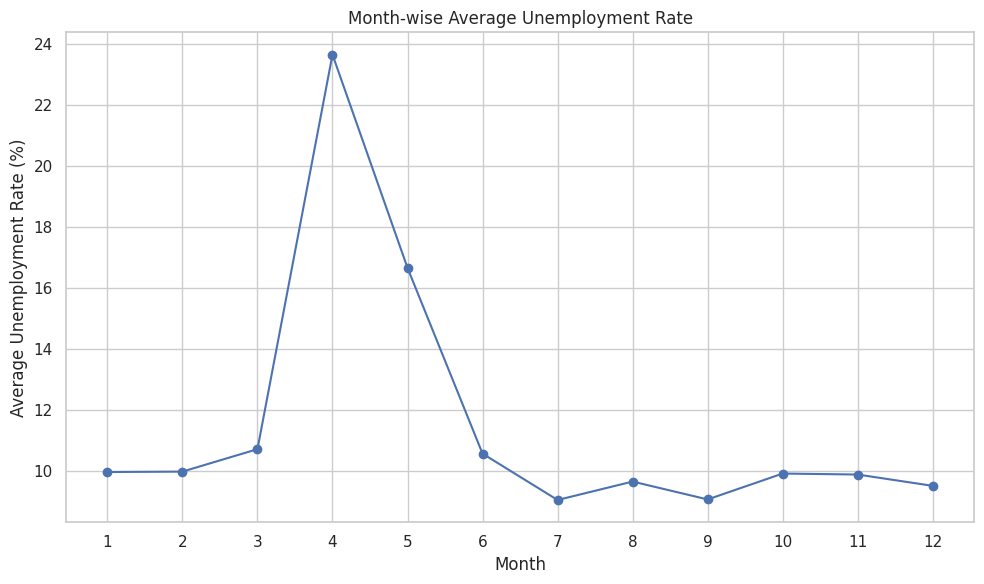

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o'
)
plt.title('Month-wise Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Observation

The monthly unemployment rate shows fluctuations throughout the year.
Certain months experience higher unemployment levels than others,
indicating temporal variation in India's employment conditions.

Time-Series Analysis — 3 Major States

In [27]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [28]:
selected_states = [
    'West Bengal',
    'Maharashtra',
    'Tamil Nadu'
]
state_data = df[df['Region'].isin(selected_states)]

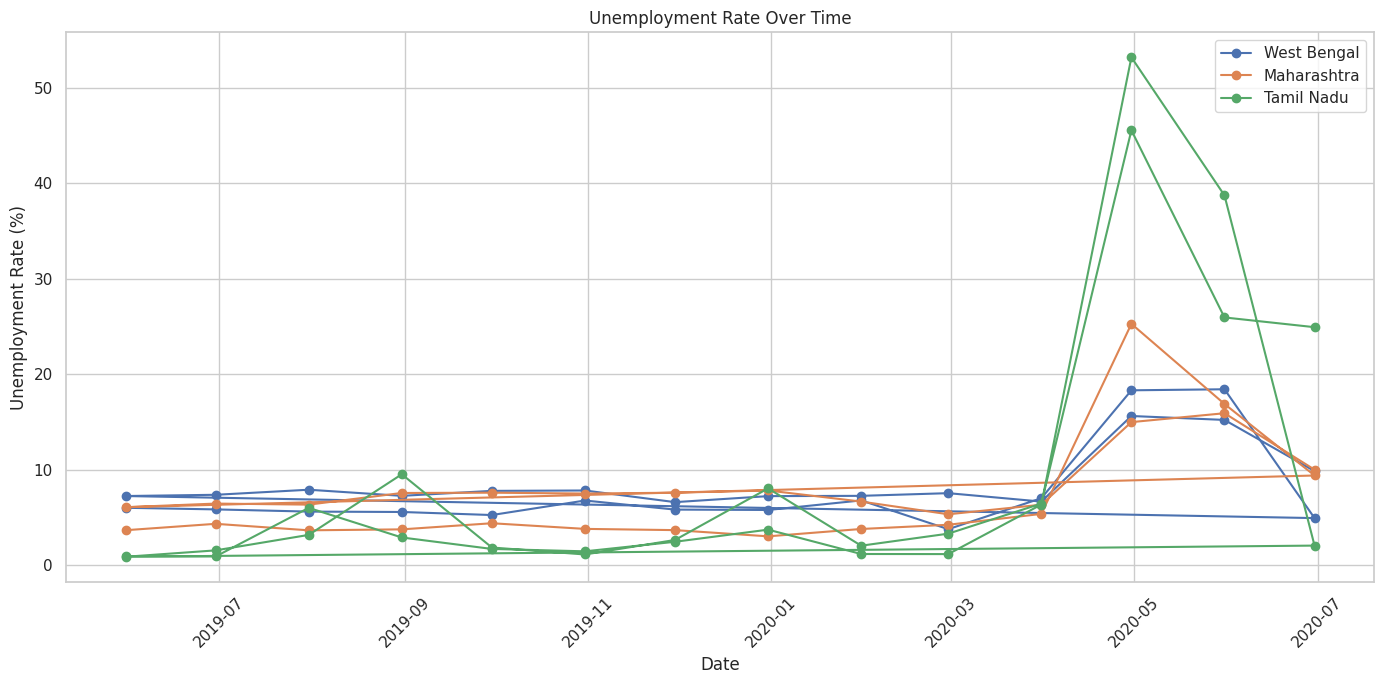

In [29]:
plt.figure(figsize=(14, 7))
for state in selected_states:
    state_df = state_data[state_data['Region'] == state]
    plt.plot(
        state_df['Date'],
        state_df['Estimated Unemployment Rate (%)'],
        marker='o',
        label=state
    )
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The unemployment rate changes significantly over time across the
selected states. The three states show different patterns and
levels of unemployment, demonstrating that the impact of economic
conditions was not uniform across India.

Top 10 States with Highest Average Unemployment

In [30]:
top_10 = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
top_10

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


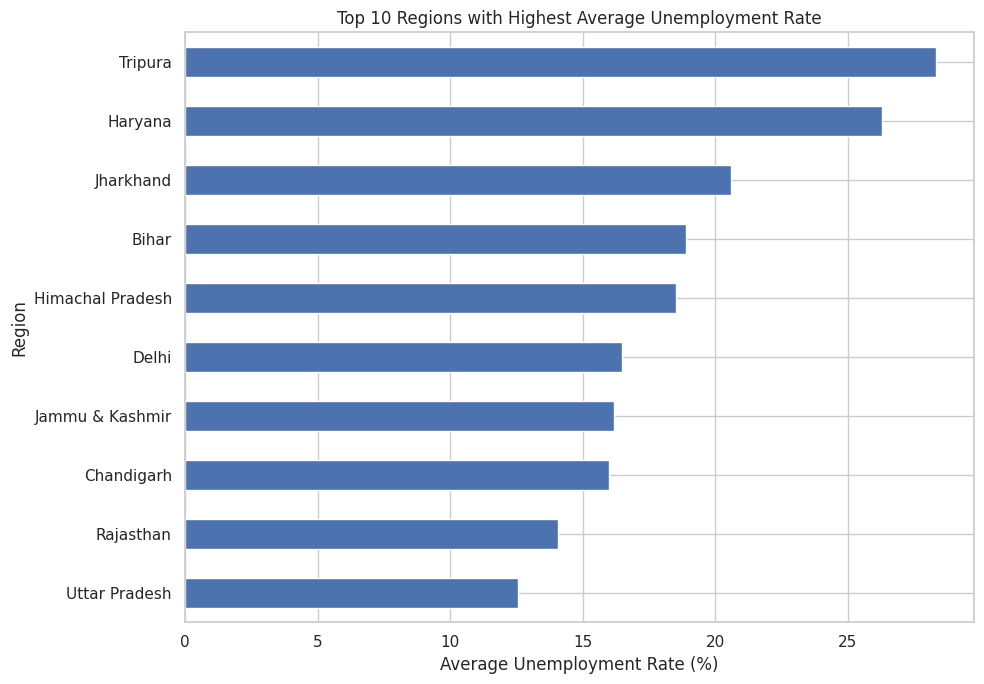

In [31]:
plt.figure(figsize=(10, 7))
top_10.sort_values().plot(
    kind='barh'
)
plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Observation

The chart identifies the ten regions with the highest average
unemployment rates in the dataset. These regions experienced
relatively greater unemployment compared with other regions
during the period covered by the dataset.

**Correlation Analysis**


In [32]:
correlation_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]
correlation_matrix = df[correlation_columns].corr()
correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


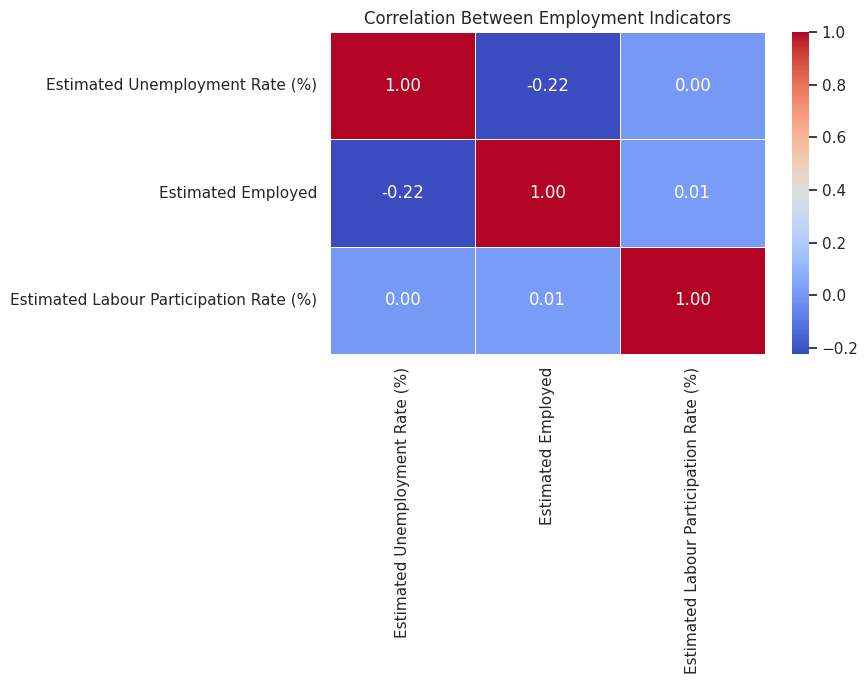

In [33]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Between Employment Indicators')
plt.tight_layout()
plt.show()

### Observation

The heatmap shows the correlation between unemployment,
employment and labour participation indicators.

A positive correlation indicates that two variables tend to
increase together, while a negative correlation indicates that
one tends to decrease as the other increases.

Correlation does not necessarily imply causation.

COVID-19 Period Analysis

In [34]:
covid_date = pd.Timestamp('2020-03-24')
df['COVID_Period'] = np.where(
    df['Date'] < covid_date,
    'Pre-COVID',
    'Post-COVID'
)
df[['Date', 'COVID_Period']].head()

,Date,COVID_Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


Pre-COVID vs Post-COVID Mean Values

In [35]:
covid_comparison = df.groupby('COVID_Period')[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].mean()
covid_comparison

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


Compare Unemployment Rate

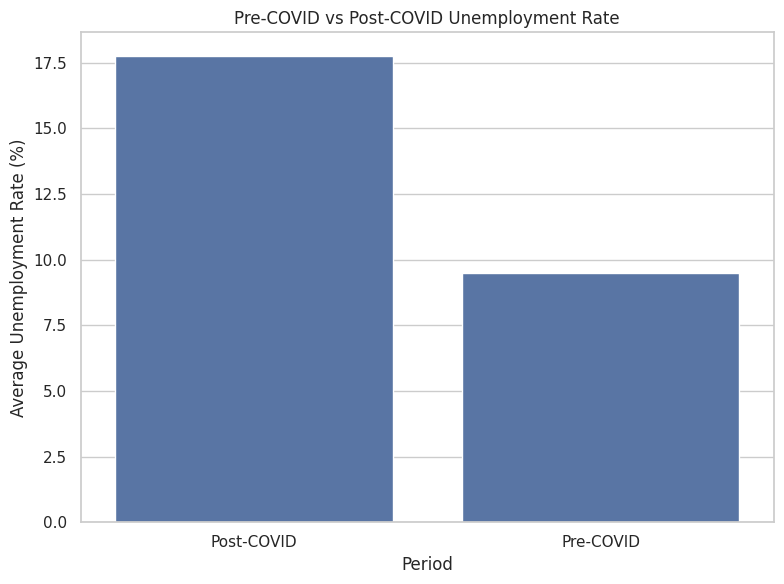

In [36]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison['Estimated Unemployment Rate (%)']
)
plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

### Observation

The comparison shows how the average unemployment rate changed
between the pre-COVID and post-COVID periods.

The difference provides an indication of how strongly unemployment
conditions changed around the COVID-19 period.

Compare Labour Participation Rate

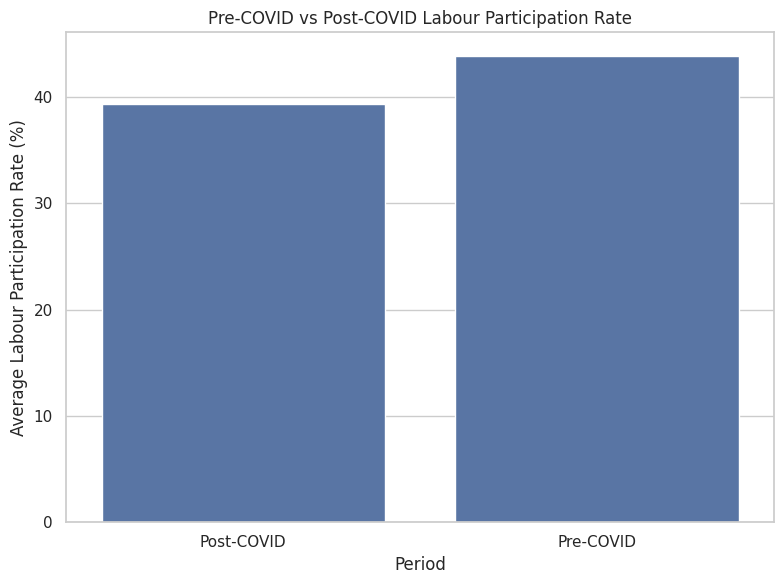

In [37]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison['Estimated Labour Participation Rate (%)']
)
plt.title('Pre-COVID vs Post-COVID Labour Participation Rate')
plt.xlabel('Period')
plt.ylabel('Average Labour Participation Rate (%)')
plt.tight_layout()
plt.show()

Compare Employment

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison['Estimated Employed']
)
plt.title('Pre-COVID vs Post-COVID Estimated Employment')
plt.xlabel('Period')
plt.ylabel('Average Estimated Employed')
plt.tight_layout()
plt.show()

COVID Impact — State-wise Analysis

In [38]:
covid_state_comparison = df.groupby(
    ['Region', 'COVID_Period']
)['Estimated Unemployment Rate (%)'].mean().unstack()
covid_state_comparison.head()

COVID_Period,Post-COVID,Pre-COVID
Region,,
Andhra Pradesh,13.576250,5.037500
Assam,6.578571,6.372632
Bihar,31.631250,13.833000
Chandigarh,14.325000,16.325000
Chhattisgarh,13.075000,7.706500


In [39]:
covid_state_comparison['Change'] = (
    covid_state_comparison['Post-COVID'] -
    covid_state_comparison['Pre-COVID']
)
covid_state_comparison.sort_values(
    'Change',
    ascending=False
).head(10)

COVID_Period,Post-COVID,Pre-COVID,Change
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550
Haryana,34.65250,22.9355,11.71700
Kerala,17.95250,6.9925,10.96000
Telangana,15.44250,4.6560,10.78650
Madhya Pradesh,14.07000,4.7410,9.32900


# Conclusion

The analysis of unemployment data in India reveals significant
regional and temporal differences in unemployment conditions.

The exploratory analysis identified regions with relatively high
average unemployment rates and showed how unemployment fluctuated
over time.

The time-series analysis of selected states demonstrated that
unemployment patterns differed across regions.

The correlation analysis provided insights into the relationships
between unemployment, estimated employment and labour participation.

Finally, the pre-COVID and post-COVID comparison highlighted changes
in India's employment conditions around the COVID-19 pandemic.

Overall, the analysis demonstrates how Python-based exploratory
data analysis and visualization can be used to understand
large-scale economic and employment trends.